# 04 — Fractional Factorial Designs: 2^(k-p)
**References:** Box & Hunter (1961) · Box, Hunter & Hunter (2005) Ch. 6 · Montgomery (2017) Ch. 8

## Narrative thread
```
Motivation (too many runs) -> 2^(k-1) half fraction -> Resolution -> Aliasing -> Design generators -> Analysis
```

## The problem with full factorials at large k

| k | 2^k runs | % of runs estimating 3FI+ |
|---|---|---|
| 4 | 16 | 31% (5 of 16 params) |
| 5 | 32 | 53% |
| 6 | 64 | 73% |
| 7 | 128 | 84% |

By the **effect hierarchy principle**, 3FI and higher are usually negligible.
We can **sacrifice** information on these to estimate main effects and 2FIs with far fewer runs.

## The 2^(k-p) fractional factorial

A $2^{k-p}$ design uses $2^{k-p}$ runs to study $k$ factors — a $1/2^p$ fraction of the full factorial.

**Key idea:** choose a **defining relation** that confounds (aliases) only high-order interactions.

### The 2^(5-2) design: 8 runs for 5 factors

Full $2^5$ = 32 runs. The half fraction $2^{5-2}$ = 8 runs, using:
- $D = AB$ (factor D confounded with 2FI AB)
- $E = AC$ (factor E confounded with 2FI AC)
- Defining relation: $I = ABD = ACE = BCDE$

## Resolution

**Resolution III:** Main effects aliased with 2FIs. Use only for screening (5–15 factors).

**Resolution IV:** Main effects clear of 2FIs, but 2FIs aliased with each other.

**Resolution V:** Main effects and 2FIs clear of each other (2FIs aliased with 3FIs only).

| Resolution | What's aliased | Use for |
|---|---|---|
| III | Main ↔ 2FI | Screening many factors |
| IV | 2FI ↔ 2FI | Characterization |
| V | 2FI ↔ 3FI | Optimization (with RSM next) |
| VI+ | 3FI+ ↔ 3FI+ | Full factorial usually preferred |

## Projection property

A $2^{k-p}_{\text{Res III}}$ design projects onto a **full $2^3$ factorial** in any 3 factors.
This means: if you find 3 active factors, you automatically have a full factorial in them!

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

2^(5-2) Design Matrix (8 runs for 5 factors):
 A(price)  B(place)  C(color)  D(font)  E(image)  Run
     -1.0      -1.0      -1.0      1.0       1.0    1
     -1.0      -1.0       1.0      1.0      -1.0    2
     -1.0       1.0      -1.0     -1.0       1.0    3
     -1.0       1.0       1.0     -1.0      -1.0    4
      1.0      -1.0      -1.0     -1.0      -1.0    5
      1.0      -1.0       1.0     -1.0       1.0    6
      1.0       1.0      -1.0      1.0      -1.0    7
      1.0       1.0       1.0      1.0       1.0    8

Aliasing structure (generators: D=AB, E=AC):
  [A] = A + BDE + CDE + ...
  [D] = D + AB + CE + ABCDE
  [AD] = AD + B + ADE + ...

Main effects A,B,C are clear of all 2FIs (Resolution V in base factors)
Estimated effects (true active: A=8, D=3=AB alias):
     A: +9.130
    CE: +9.130
    BD: +9.130
    BE: -1.876
    CD: -1.876
     E: +1.104
    AC: +1.104
    BC: +0.776
    DE: +0.776
    AE: -0.505
     C: -0.505
     D: -0.373
    AB: -0.373
    AD: -0.025
   

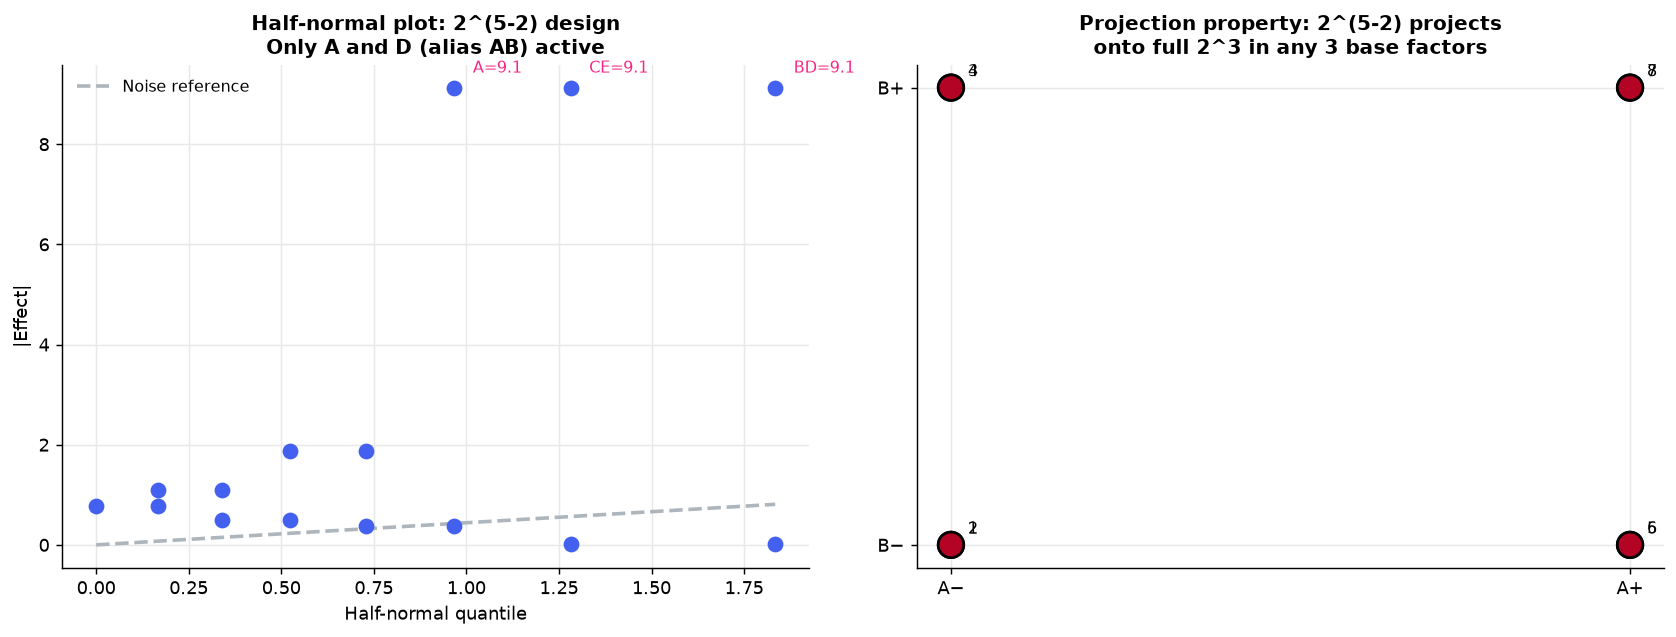

In [2]:
# ── 2^(5-2) design: construct and analyze ────────────────────────────────
# 5 factors: A (price), B (placement), C (color), D (font size), E (image)
# 8 runs instead of 32

# Build from 2^3 base (A,B,C in standard order)
base_23 = np.array(list(product([-1,1], repeat=3)), dtype=float)
A_col = base_23[:,0]; B_col = base_23[:,1]; C_col = base_23[:,2]

D_col = A_col * B_col      # D = AB (generator)
E_col = A_col * C_col      # E = AC (generator)

design_52 = np.column_stack([A_col, B_col, C_col, D_col, E_col])
factor_names_52 = ['A(price)','B(place)','C(color)','D(font)','E(image)']

print('2^(5-2) Design Matrix (8 runs for 5 factors):')
df_design = pd.DataFrame(design_52, columns=factor_names_52)
df_design['Run'] = np.arange(1, 9)
print(df_design.to_string(index=False))

print()
print('Aliasing structure (generators: D=AB, E=AC):')
print('  [A] = A + BDE + CDE + ...')
print('  [D] = D + AB + CE + ABCDE')
print('  [AD] = AD + B + ADE + ...')
print()
print('Main effects A,B,C are clear of all 2FIs (Resolution V in base factors)')

# True effects: only A and interaction AB (=D) active
np.random.seed(17)
true_A = 8.0; true_D = 3.0   # true_D is really AB
y_true = 50 + true_A*(A_col/2) + true_D*(D_col/2) + np.random.normal(0, 2, 8)

# Estimate effects from contrasts (no replication: n=8, p=1)
n8 = 8
col_dict = {'A':A_col,'B':B_col,'C':C_col,'D':D_col,'E':E_col,
            'AB':A_col*B_col,'AC':A_col*C_col,'BC':B_col*C_col,
            'AE':A_col*E_col,'BE':B_col*E_col,'CE':C_col*E_col,
            'AD':A_col*D_col,'BD':B_col*D_col,'CD':C_col*D_col,'DE':D_col*E_col}
effects = {k: (v @ y_true)/(n8/2) for k,v in col_dict.items()}

print('Estimated effects (true active: A=8, D=3=AB alias):')
for k,v in sorted(effects.items(), key=lambda x:-abs(x[1])):
    print(f'  {k:>4}: {v:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Half-normal plot
abs_eff = np.sort(np.abs(list(effects.values())))
n_e = len(abs_eff)
hn_probs = np.abs(stats.norm.ppf((np.arange(1,n_e+1)-0.5)/n_e))
n_null = n_e // 2
slope_null = abs_eff[:n_null].mean() / hn_probs[:n_null].mean()

axes[0].scatter(hn_probs, abs_eff, s=60, color='#4361ee', zorder=3)
axes[0].plot(np.linspace(0,hn_probs.max(),100), slope_null*np.linspace(0,hn_probs.max(),100),
             '--', color='#adb5bd', lw=2, label='Noise reference')
for (k, v), p in zip(sorted(effects.items(), key=lambda x:abs(x[1])), hn_probs):
    if abs(v) > 3:
        axes[0].annotate(f'{k}={v:.1f}', (p, abs(v)),
                         xytext=(p+0.05, abs(v)+0.3), fontsize=9, color='#f72585')
axes[0].set_xlabel('Half-normal quantile')
axes[0].set_ylabel('|Effect|')
axes[0].set_title('Half-normal plot: 2^(5-2) design\nOnly A and D (alias AB) active')
axes[0].legend(fontsize=9)

# Projection: show that 8 runs project to full 2^3 in (A,B,C)
axes[1].scatter(A_col, B_col, c=C_col, s=200, cmap='coolwarm',
                edgecolors='black', lw=1.5, zorder=3)
for i in range(8):
    axes[1].text(A_col[i]+0.05, B_col[i]+0.05, f'{i+1}', fontsize=9)
axes[1].set_xticks([-1,1]); axes[1].set_xticklabels(['A−','A+'])
axes[1].set_yticks([-1,1]); axes[1].set_yticklabels(['B−','B+'])
axes[1].set_title('Projection property: 2^(5-2) projects\nonto full 2^3 in any 3 base factors')
plt.tight_layout()
plt.show()